<a href="https://colab.research.google.com/github/freditasariph/Praktikum-ADW/blob/main/Tugas_Minggu_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<h1><center> MODEL STASIONER </center></h1><center>KELOMPOK 3</center>

<center>
_____________________________________________________________________________________________________________________________
</center>


<h2> TUGAS KELOMPOK </h2>

Masing-masing kelompok gunakan set.seed jumlah 2 digit terakhir NIM semua anggota kelompok.

1. Buatlah simulasi deret MA (1) dengan panjang pengamatan 20 dengan nilai parameter $\theta=0.1, \theta=0.3, \theta=0.7, \theta=1.0, \theta=1.5, \theta=2.0$
   
2. Buatlah plot ACF dari masing-masing deret hasil simulasi yang Anda peroleh pada nomor 1 dan bandingkan. Berdasarkan plot ACF tersebut, apa yang dapat Anda simpulkan terkait nilai autokorelasi pada lag 1 pada model MA(1)? (Hint: Identifikasi pola nilai autokorelasi berdasarkan nilai parameter MA, kaitkan nilai autokorelasi sampel dengan nilai autokorelasi MA(1) secara teori.)

3. Buatlah simulasi deret MA (1) dengan parameter $\theta=0.25$ dengan panjang pengamatan 60, 100,150, 300.

4. Buatlah plot ACF dari masing-masing deret hasil simulasi yang Anda peroleh pada nomor 3 dan bandingkan. Berdasarkan plot ACF tersebut apa yang dapat Anda simpulkan terkait nilai autokorelasi pada lag 1 pada model MA(1)? (Hint: Identifikasi pola interval kepercayaan dari nilai autokorelasi berdasarkan panjang observasi.)

5. Buatlah simulasi deret MA (2) dengan panjang pengamatan 50 dengan parameter:
   
   a. $\theta_1=0.3, \theta_2=0.8$
   
   b. $\theta_1=-0.3, \theta_2=0.8$
   
   c. $\theta_1=0.3, \theta_2=-0.8$
   
   d. $\theta_1=-0.3, \theta_2=-0.8$

6. Buatlah plot ACF dari masing-masing deret hasil simulasi yang Anda peroleh pada nomor 5 dan bandingkan. Berdasarkan plot ACF tersebut apa yang dapat Anda simpulkan terkait nilai autokorelasi pada lag 1 dan 2 dari deret MA(2)? (Hint: Identifikasi pola nilai autokorelasi berdasarkan nilai parameter MA.)

7. Buatlah simulasi deret AR (1) 100 pengamatan dengan nilai parameter $\phi=0.3, \phi=0.9, \phi=-0.3, \phi=-0.9$

8. Buatlah plot ACF dan PACF dari masing-masing deret hasil simulasi yang Anda peroleh pada nomor 7 dan bandingkan. Berdasarkan plot ACF dan PACF tersebut apa yang dapat Anda simpulkan terkait nilai autokorelasi pada deret AR(1)? (Hint: Identifikasi pola nilai autokorelasi ataupun autokorelasi parsial berdasarkan nilai parameter AR.)

9. Berdasarkan plot ACF dan PACF pada nomor 8, model apa yang disarankan untuk masing-masing deret? Jelaskan jawaban Anda.

10. Buatlah simulasi deret AR (2) dengan panjang pengamatan 100 dengan parameter:
   
     a. $\phi_1=1.5, \phi_2=-0.5$
   
     b. $\phi_1=0.75, \phi_2=-0.25$
   
     c. $\phi_1=1, \phi_2=-0.25$
   
    d. $\phi_1=0.5, \phi_2=-0.75$
   
11. Buatlah plot ACF dan PACF dari masing-masing deret hasil simulasi yang Anda peroleh pada nomor 10. Berdasarkan plot ACF dan PACF tersebut apa yang dapat Anda simpulkan terkait nilai autokorelasi pada deret AR(2)? (Hint: Identifikasi pola nilai autokorelasi ataupun autokorelasi parsial berdasarkan nilai parameter AR.)

12. Berdasarkan plot ACF dan PACF pada nomor 11, model apa yang disarankan untuk masing-masing deret? Jelaskan jawaban Anda.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import acf

from statsmodels.tsa.arima_process import ArmaProcess
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

import warnings
warnings.filterwarnings("ignore")

<h1> Rataan Bergerak (Moving Average) </h1>

Diberikan suatu deret waktu ${Y_t}$, dan deret white noise yang tidak teramati ${e_t}$, yaitu barisan peubah acak yang saling bebas dan memiliki sebaran identik dengan nilai tengah nol.

Proses rataan bergerak (moving average) secara umum atau MA (q) dapat dinyatakan dalam model sebagai berikut:

<center> $Y_t=e_t-\theta_1 e_{t-1}-\theta_2 e_{t-2}-...-\theta_q e_{t-q}$</center>

## MA (1)

Proses MA(1) memiliki persamaan:

<center> $Y_t=e_t-\theta e_{t-1}$ </center>



- dengan panjang pengamatan 20 dengan nilai parameter $\theta=0.1, \theta=0.3, \theta=0.7, \theta=1.0, \theta=1.5, \theta=2.0$

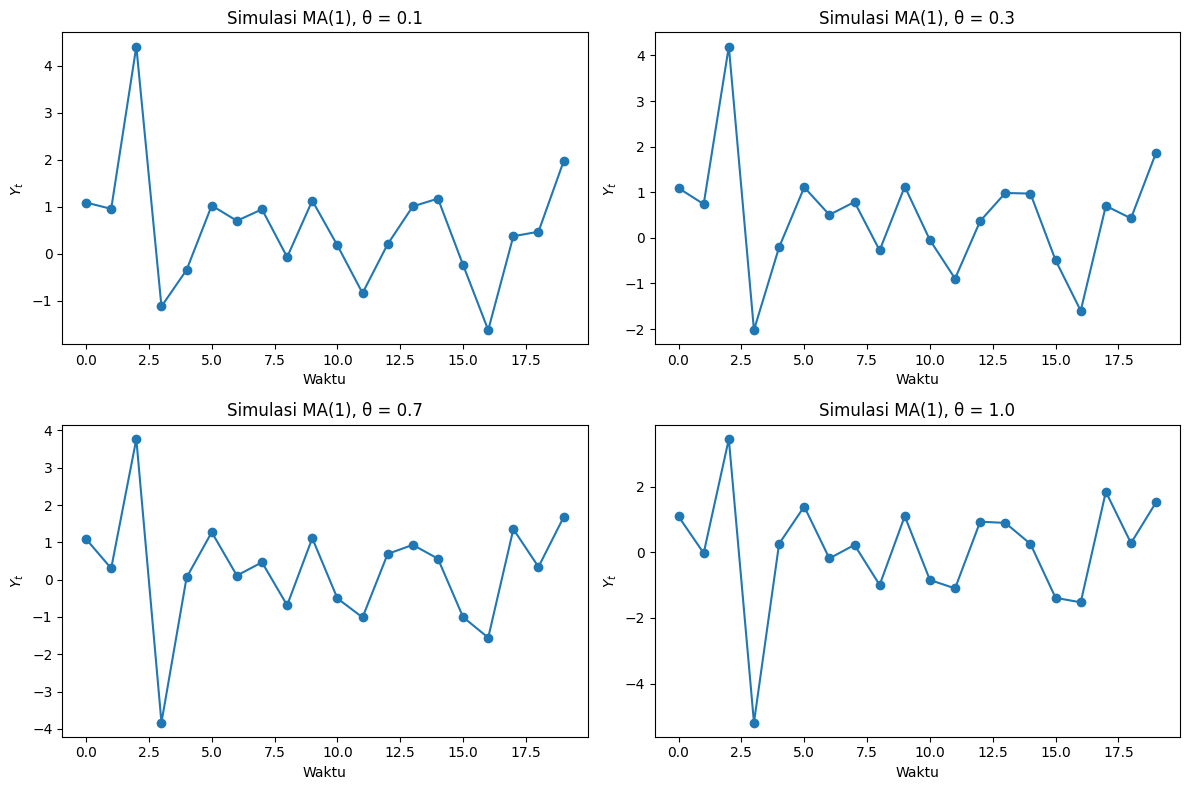

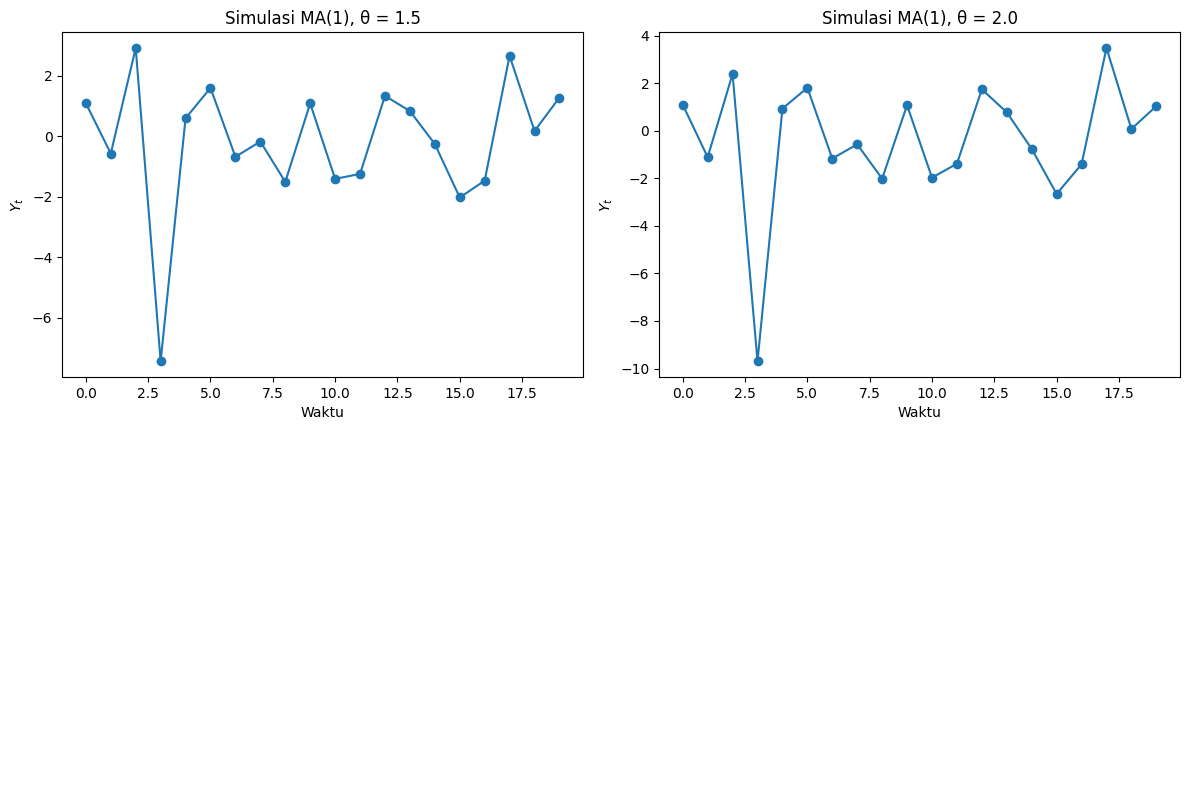

In [ ]:
# Nomor 1
# Simulasi deret MA(1) dengan panjang pengamatan 20

theta_values = [0.1, 0.3, 0.7, 1.0, 1.5, 2.0]
n = 20

hasil_ma1_theta = {}

for theta in theta_values:

    # seed kelompok
    np.random.seed(137)

    # Parameter model MA(1)
    ar_params = np.array([1])
    ma_params = np.array([1, -theta])

    # Membentuk proses MA(1)
    ma_object = ArmaProcess(ar_params, ma_params)

    # Simulasi data
    data_ma1 = ma_object.generate_sample(nsample=n)

    # Menyimpan hasil simulasi
    hasil_ma1_theta[theta] = data_ma1

    # Plot deret waktu
for start in range(0, len(theta_values), 4):
    fig, axes = plt.subplots(2, 2, figsize=(12, 8))
    axes = axes.flatten()

    subset_theta = theta_values[start:start+4]

    for i, theta in enumerate(subset_theta):
        axes[i].plot(hasil_ma1_theta[theta], '-o')
        axes[i].set_title(f'Simulasi MA(1), θ = {theta}')
        axes[i].set_xlabel('Waktu')
        axes[i].set_ylabel(r'$Y_t$')

    for j in range(len(subset_theta), 4):
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()

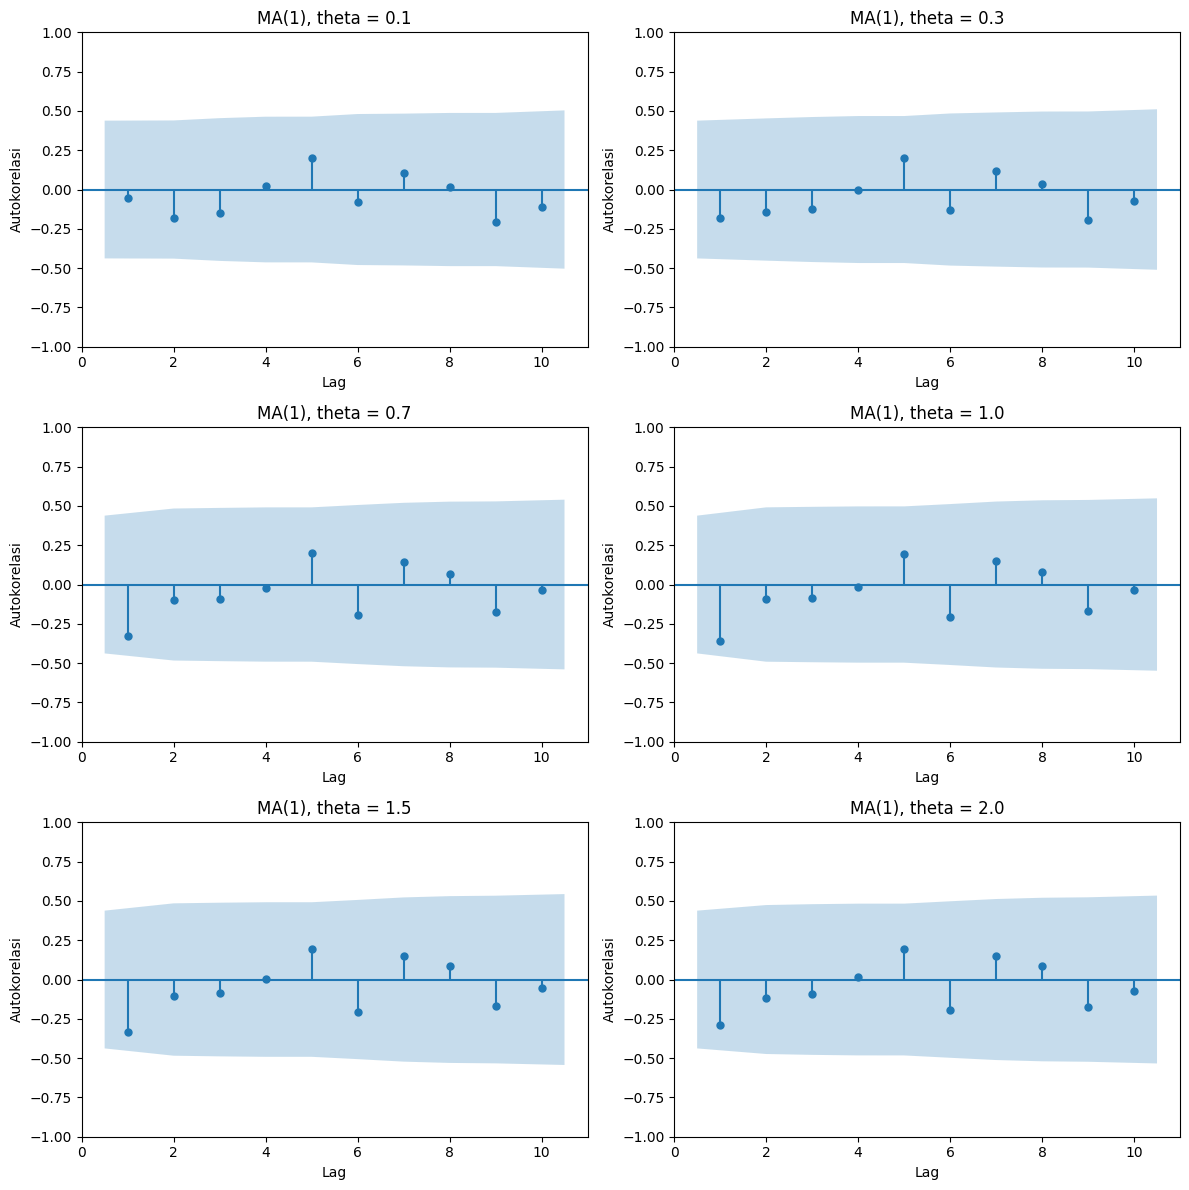

In [ ]:
# Nomor 2
# Plot ACF dari setiap simulasi MA(1) pada nomor 1

fig, axes = plt.subplots(3, 2, figsize=(12, 12))

axes = axes.flatten()

for i, theta in enumerate(theta_values):

    plot_acf(
        hasil_ma1_theta[theta],
        zero=False,
        lags=10,
        ax=axes[i]
    )

    axes[i].set_title(f'MA(1), theta = {theta}')
    axes[i].set_xlabel('Lag')
    axes[i].set_ylabel('Autokorelasi')

plt.tight_layout()
plt.show()

In [ ]:
# Perbandingan ACF sampel lag 1 dan ACF teoritis MA(1)

hasil_acf = []

for theta in theta_values:

    # ACF sampel pada lag 1
    acf_sample = acf(
        hasil_ma1_theta[theta],
        nlags=1,
        fft=False
    )[1]

    # ACF teoritis MA(1)
    acf_theory = -theta / (1 + theta**2)

    hasil_acf.append({
        'Theta': theta,
        'ACF Sampel Lag 1': acf_sample,
        'ACF Teoritis Lag 1': acf_theory
    })

# Membuat tabel
tabel_acf = pd.DataFrame(hasil_acf)
tabel_acf = tabel_acf.round(3)
display(tabel_acf)

,Theta,ACF Sampel Lag 1,ACF Teoritis Lag 1
0,0.1,-0.054,-0.099
1,0.3,-0.182,-0.275
2,0.7,-0.330,-0.470
3,1.0,-0.357,-0.500
4,1.5,-0.334,-0.462
5,2.0,-0.290,-0.400


- dengan parameter $\theta=0.25$ dengan panjang pengamatan 60, 100,150, 300.

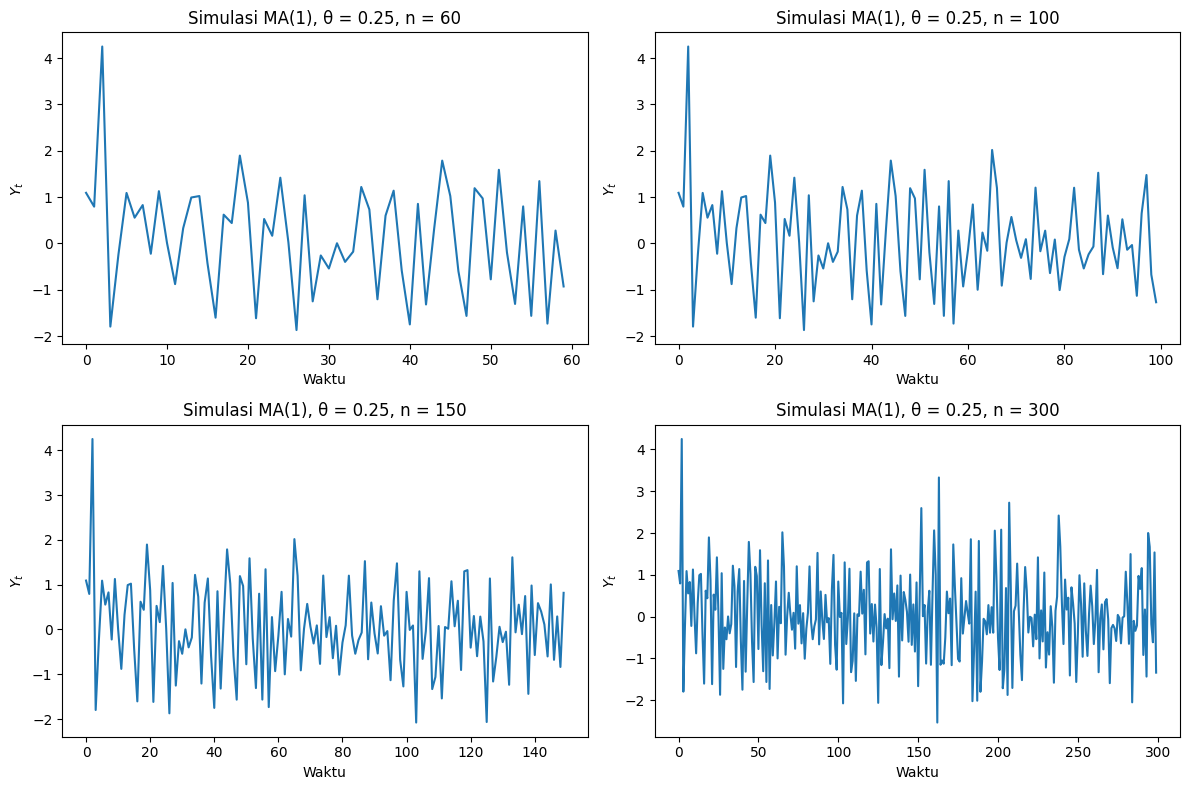

In [ ]:
# Nomor 3
# Simulasi MA(1) theta = 0.25

theta = 0.25
n_values = [60, 100, 150, 300]

hasil_ma1_n = {}

for n in n_values:

    # seed kelompok
    np.random.seed(137)

    # Parameter model
    ar_params = np.array([1])
    ma_params = np.array([1, -theta])

    # Membentuk proses MA(1)
    ma_object = ArmaProcess(ar_params, ma_params)

    # Simulasi data
    data_ma1 = ma_object.generate_sample(nsample=n)

    # Menyimpan hasil simulasi
    hasil_ma1_n[n] = data_ma1

    # Plot deret waktu
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for i, n in enumerate(n_values):
    axes[i].plot(hasil_ma1_n[n])
    axes[i].set_title(f'Simulasi MA(1), θ = {theta}, n = {n}')
    axes[i].set_xlabel('Waktu')
    axes[i].set_ylabel(r'$Y_t$')

plt.tight_layout()
plt.show()

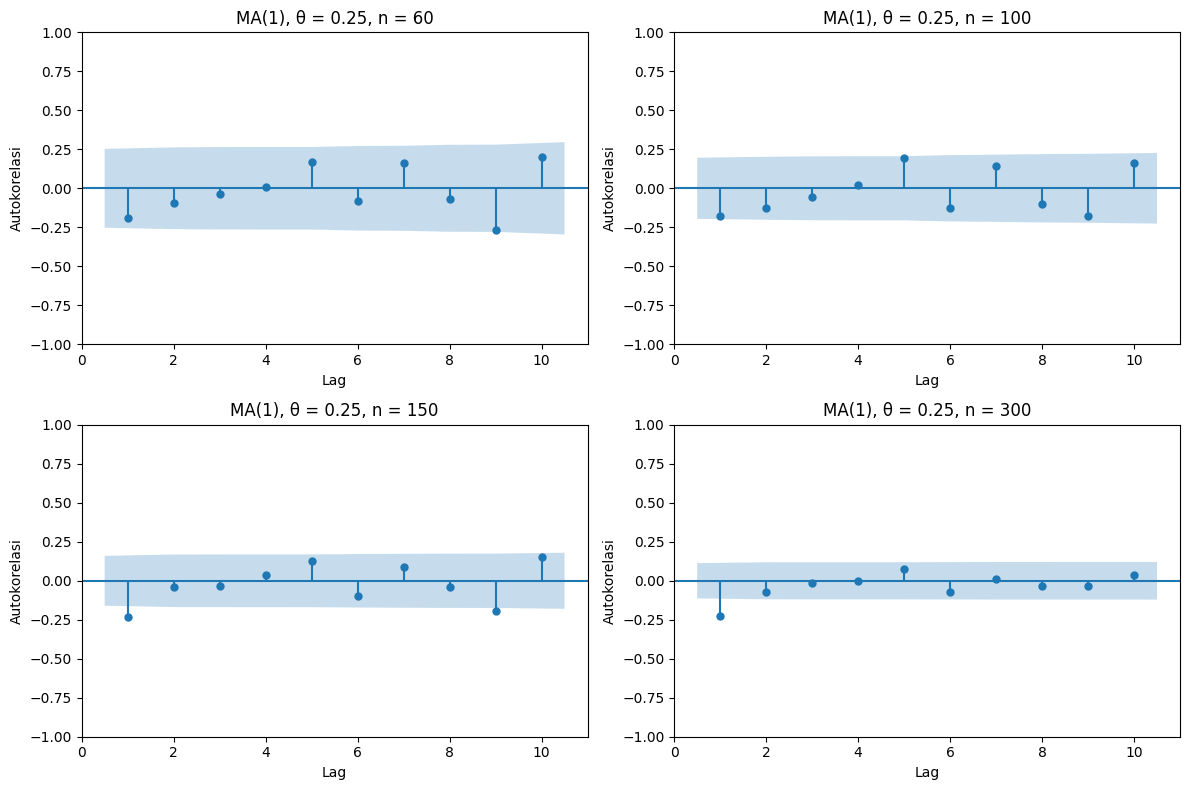

In [ ]:
# Nomor 4
# Plot ACF untuk berbagai panjang pengamatan

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for i, n in enumerate(n_values):

    plot_acf(
        hasil_ma1_n[n],
        zero=False,
        lags=10,
        ax=axes[i]
    )

    axes[i].set_title(f'MA(1), θ = 0.25, n = {n}')
    axes[i].set_xlabel('Lag')
    axes[i].set_ylabel('Autokorelasi')

plt.tight_layout()
plt.show()

In [ ]:
# Perbandingan ACF lag 1 berdasarkan panjang pengamatan

hasil_acf_n = []

# ACF teoritis MA(1) untuk theta = 0.25
acf_teoritis = -theta / (1 + theta**2)

for n in n_values:

    # Menghitung ACF sampel sampai lag 1
    acf_sample = acf(
        hasil_ma1_n[n],
        nlags=1,
        fft=False
    )[1]

    # Pendekatan batas interval kepercayaan 95%
    batas_ci = 1.96 / np.sqrt(n)

    hasil_acf_n.append({
        'n': n,
        'ACF Sampel Lag 1': acf_sample,
        'ACF Teoritis Lag 1': acf_teoritis,
        'Batas Bawah CI 95%': -batas_ci,
        'Batas Atas CI 95%': batas_ci,
        'Lebar CI': 2 * batas_ci
    })

# Membuat DataFrame
tabel_acf_n = pd.DataFrame(hasil_acf_n)
tabel_acf_n = tabel_acf_n.round(3)
display(tabel_acf_n)

,n,ACF Sampel Lag 1,ACF Teoritis Lag 1,Batas Bawah CI 95%,Batas Atas CI 95%,Lebar CI
0,60,-0.191,-0.235,-0.253,0.253,0.506
1,100,-0.176,-0.235,-0.196,0.196,0.392
2,150,-0.235,-0.235,-0.160,0.160,0.320
3,300,-0.225,-0.235,-0.113,0.113,0.226


## MA (2)

Proses MA (2) memiliki persamaan:

<center> $Y_t=e_t-\theta_1 e_{t-1}-\theta_2 e_{t-2}$ </center>

dengan panjang pengamatan 50 dengan nilai parameter $θ$ :

   a. $\theta_1=0.3, \theta_2=0.8$
   
   b. $\theta_1=-0.3, \theta_2=0.8$
   
   c. $\theta_1=0.3, \theta_2=-0.8$
   
   d. $\theta_1=-0.3, \theta_2=-0.8$

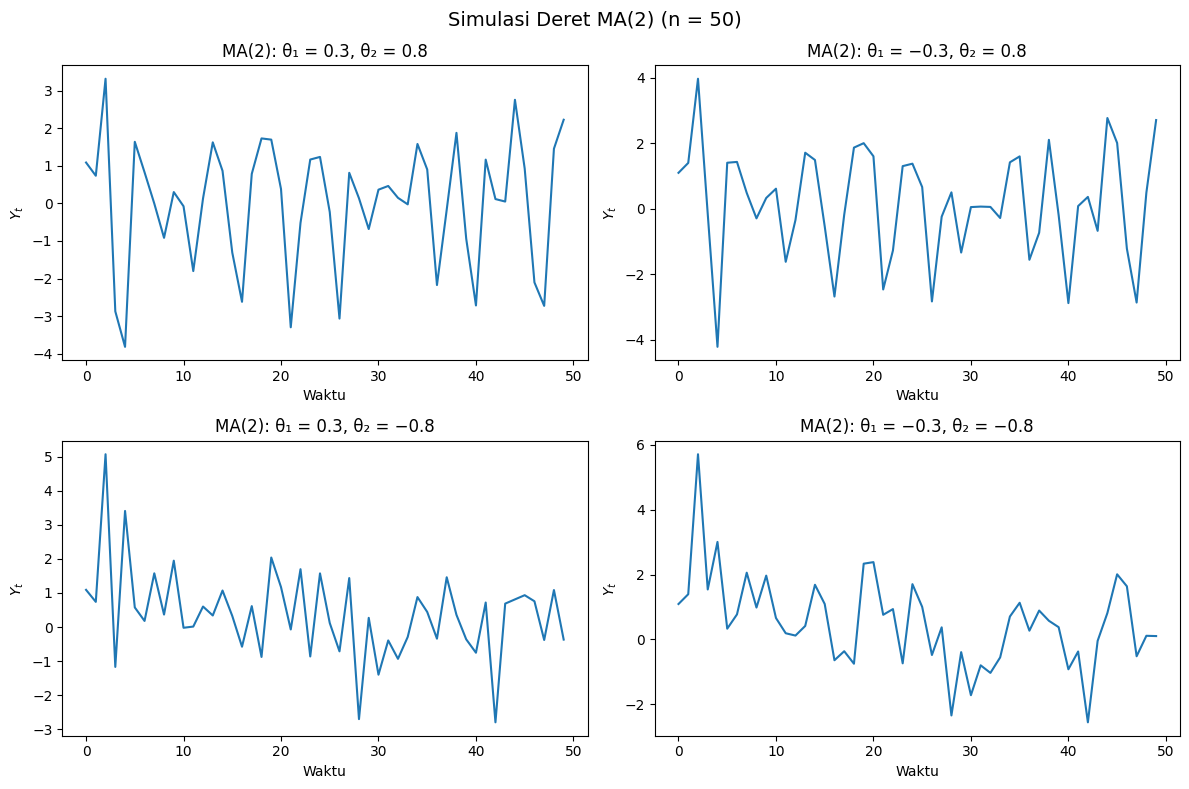

In [ ]:
# Nomor 5
# Simulasi deret MA(2) dengan panjang pengamatan 50

# Model a.
np.random.seed(137)
ar1 = np.array([1])
ma1 = np.array([1, -0.3, -0.8])
ma_object2 = ArmaProcess(ar1,ma1)
ma_model1 = ma_object2.generate_sample(nsample=50)

# Model b.
np.random.seed(137)
ar1 = np.array([1])
ma1 = np.array([1, 0.3, -0.8])
ma_object2 = ArmaProcess(ar1,ma1)
ma_model2 = ma_object2.generate_sample(nsample=50)

# Model c.
np.random.seed(137)
ar1 = np.array([1])
ma1 = np.array([1, -0.3, 0.8])
ma_object2 = ArmaProcess(ar1,ma1)
ma_model3 = ma_object2.generate_sample(nsample=50)

# Model d.
np.random.seed(137)
ar1 = np.array([1])
ma1 = np.array([1, 0.3, 0.8])
ma_object2 = ArmaProcess(ar1,ma1)
ma_model4 = ma_object2.generate_sample(nsample=50)

# Simulasi Deret MA(2)
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
models = [ma_model1, ma_model2, ma_model3, ma_model4]
labels = [
    'MA(2): θ₁ = 0.3, θ₂ = 0.8',
    'MA(2): θ₁ = −0.3, θ₂ = 0.8',
    'MA(2): θ₁ = 0.3, θ₂ = −0.8',
    'MA(2): θ₁ = −0.3, θ₂ = −0.8'
]
for i, (ax, data) in enumerate(zip(axes.flat, models), 1):
    ax.plot(data)
    ax.set_title(labels[i-1])
    ax.set_xlabel('Waktu')
    ax.set_ylabel(r'$Y_t$')
fig.suptitle('Simulasi Deret MA(2) (n = 50)', fontsize=14)
plt.tight_layout()
plt.show()

**Plot ACF (*Autocorelation Function*)**

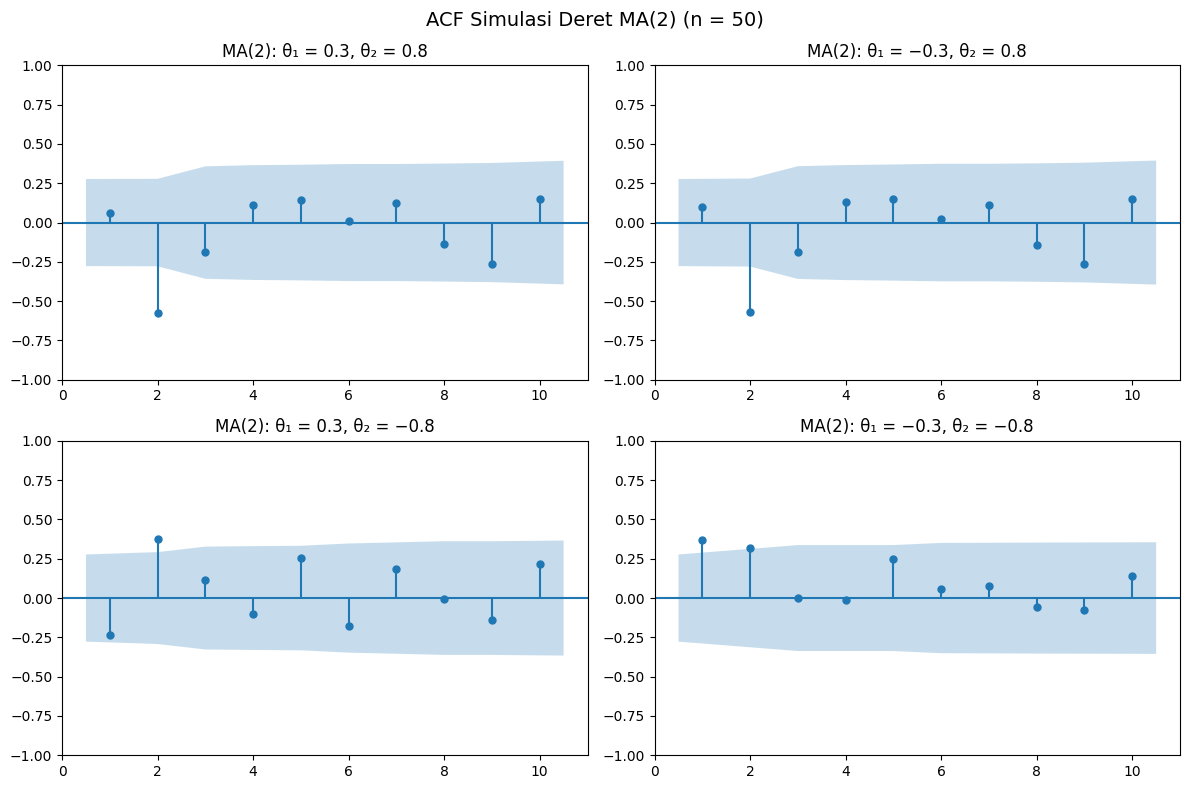

In [ ]:
# Nomor 6
# Plot ACF berbagai parameter yang telah di tentukan
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
models = [ma_model1, ma_model2, ma_model3, ma_model4]
labels = [
    'MA(2): θ₁ = 0.3, θ₂ = 0.8',
    'MA(2): θ₁ = −0.3, θ₂ = 0.8',
    'MA(2): θ₁ = 0.3, θ₂ = −0.8',
    'MA(2): θ₁ = −0.3, θ₂ = −0.8'
]
for i, (ax, data) in enumerate(zip(axes.flat, models), 1):
    plot_acf(data, lags=10, zero=False, ax=ax)
    ax.set_title(labels[i-1].replace('MA(2)', 'MA(2)'))
fig.suptitle('ACF Simulasi Deret MA(2) (n = 50)', fontsize=14)
plt.tight_layout()
plt.show()

<h2> AR (1) </h2>

Proses AR (1) memiliki persamaan:

<center> $Y_t=\phi Y_{t-1}+e_t$ </center>

dengan panjang pengamatan 100 dengan nilai parameter $\phi=0.3, \phi=0.9, \phi=-0.3, \phi=-0.9$

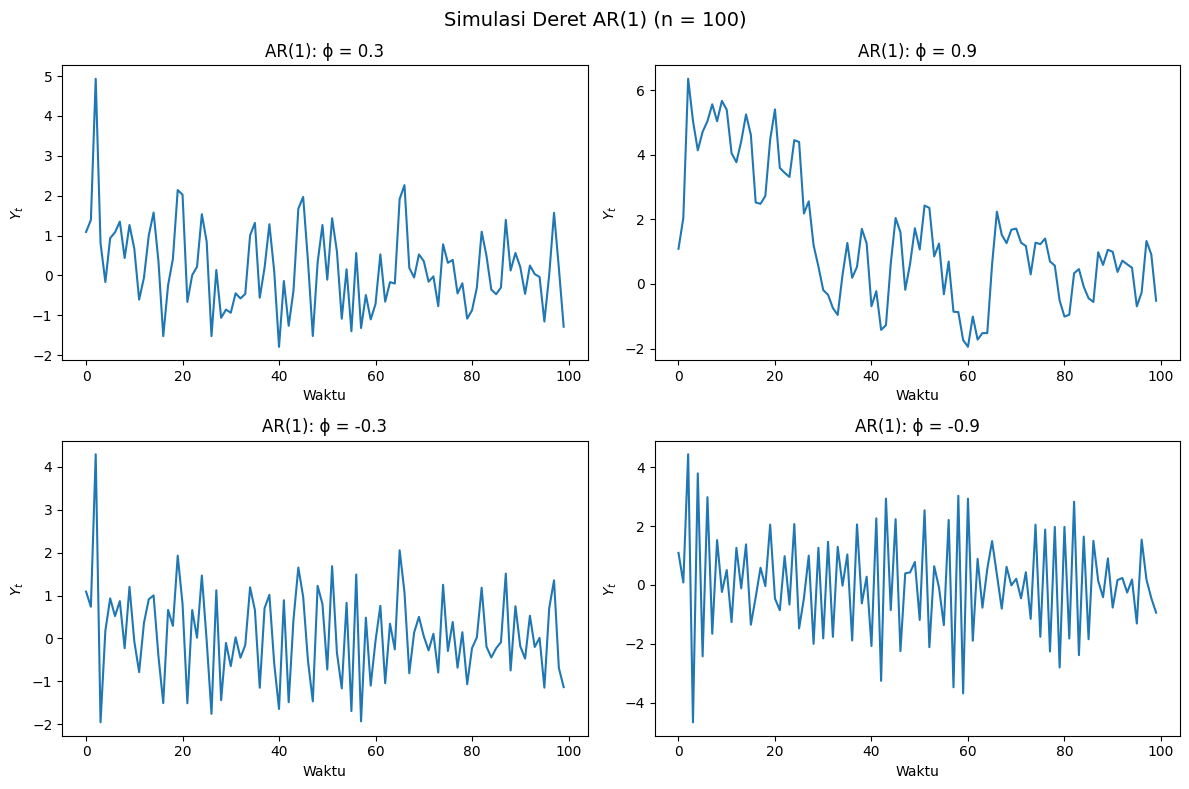

In [ ]:
# Nomor 7
# Simulasi deret AR(1) dengan panjang pengamatan 100

# parameter ϕ = 0.3
np.random.seed(137)
ar1 = np.array([1, -0.3])
ma1 = np.array([1])
ar_object1 = ArmaProcess(ar1,ma1)
ar_model1 = ar_object1.generate_sample(nsample=100)

# parameter ϕ = 0.9
np.random.seed(137)
ar1 = np.array([1, -0.9])
ma1 = np.array([1])
ar_object1 = ArmaProcess(ar1,ma1)
ar_model2 = ar_object1.generate_sample(nsample=100)

# parameter ϕ = -0.3
np.random.seed(137)
ar1 = np.array([1, 0.3])
ma1 = np.array([1])
ar_object1 = ArmaProcess(ar1,ma1)
ar_model3 = ar_object1.generate_sample(nsample=100)

# parameter ϕ = -0.9
np.random.seed(137)
ar1 = np.array([1, 0.9])
ma1 = np.array([1])
ar_object1 = ArmaProcess(ar1,ma1)
ar_model4 = ar_object1.generate_sample(nsample=100)

# Simulasi Deret AR(1)
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
models = [ar_model1, ar_model2, ar_model3, ar_model4]
labels = [
    'AR(1): ϕ = 0.3',
    'AR(1): ϕ = 0.9',
    'AR(1): ϕ = -0.3',
    'AR(1): ϕ = -0.9'
]
for i, (ax, data) in enumerate(zip(axes.flat, models), 1):
    ax.plot(data)
    ax.set_title(labels[i-1])
    ax.set_xlabel('Waktu')
    ax.set_ylabel(r'$Y_t$')
fig.suptitle('Simulasi Deret AR(1) (n = 100)', fontsize=14)
plt.tight_layout()
plt.show()

**Plot ACF (*Autocorelation Function*) dan PACF(*Partial Autocorelation Function*)**

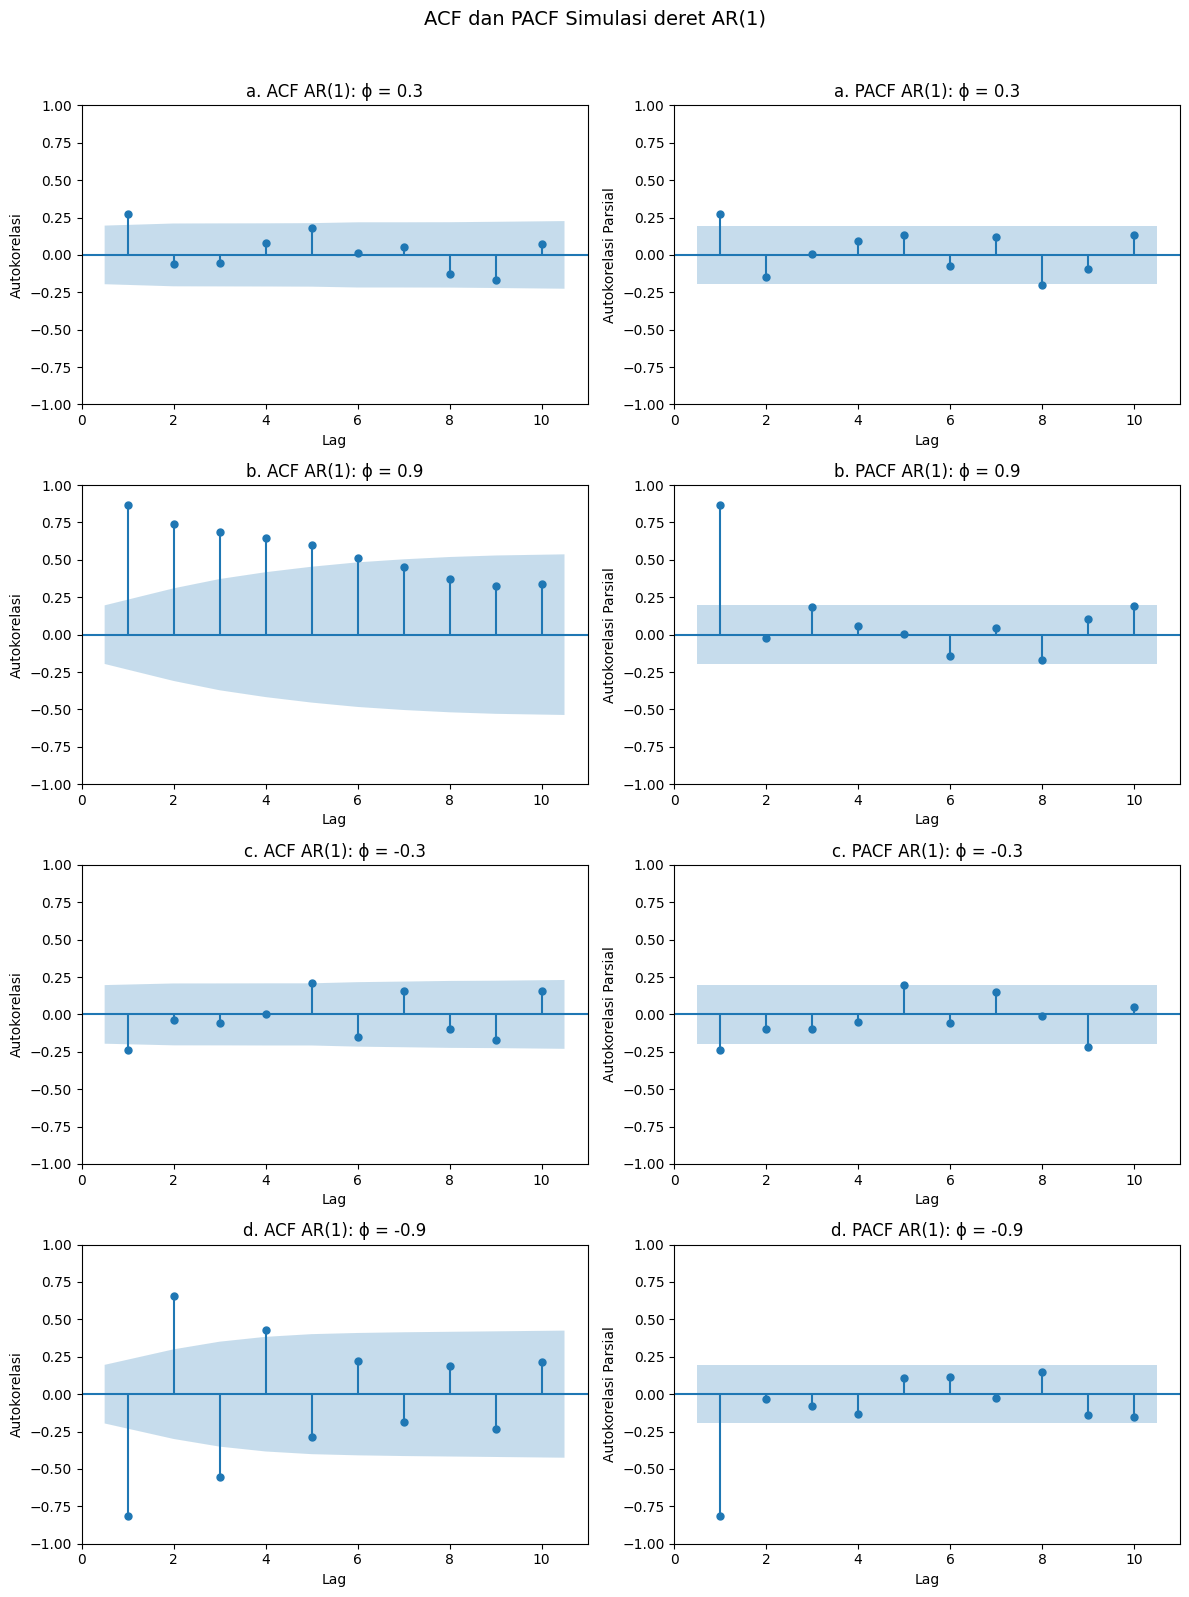

In [ ]:
# Nomor 8
# Plot ACF dan PACF berbagai parameter yang telah di tentukan

fig, axes = plt.subplots(4, 2, figsize=(12, 16))
models = [ar_model1, ar_model2, ar_model3, ar_model4]
phi_values = [0.3, 0.9, -0.3, -0.9]
labels = ['a.', 'b.', 'c.', 'd.']
for i, (data, phi, label) in enumerate(zip(models, phi_values, labels)):
    # ACF di sebelah kiri
    plot_acf(data, lags=10, zero=False, ax=axes[i, 0])
    axes[i, 0].set_title(f'{label} ACF AR(1): ϕ = {phi}')
    axes[i, 0].set_xlabel('Lag')
    axes[i, 0].set_ylabel('Autokorelasi')

    # PACF di sebelah kanan
    plot_pacf(data, lags=10, zero=False, ax=axes[i, 1], method='ywm')
    axes[i, 1].set_title(f'{label} PACF AR(1): ϕ = {phi}')
    axes[i, 1].set_xlabel('Lag')
    axes[i, 1].set_ylabel('Autokorelasi Parsial')

fig.suptitle('ACF dan PACF Simulasi deret AR(1)', fontsize=14, y=0.995)
plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.show()

<h2> AR (2) </h2>

Proses AR (2) memiliki persamaan:

<center> $Y_t=\phi_1 Y_{t-1}+\phi_2 Y_{t-2}+e_t$ </center>

**Syarat kestasioneran untuk deret AR (2) adalah jika dan hanya jika tiga kondisi berikut terpenuhi, yaitu:**

**<center> $\phi_1+\phi_2<1$  ,   $\phi_2-\phi_1<1$ ,   $|\phi_2|<1$ </center>**

Kita simulasikan deret AR (2) dengan panjang pengamatan 100 dengan parameter:
   
   a. $\phi_1=1.5, \phi_2=-0.5$

   b. $\phi_1=0.75, \phi_2=-0.25$

   c. $\phi_1=1, \phi_2=-0.25$

   d. $\phi_1=0.5, \phi_2=-0.75$
   


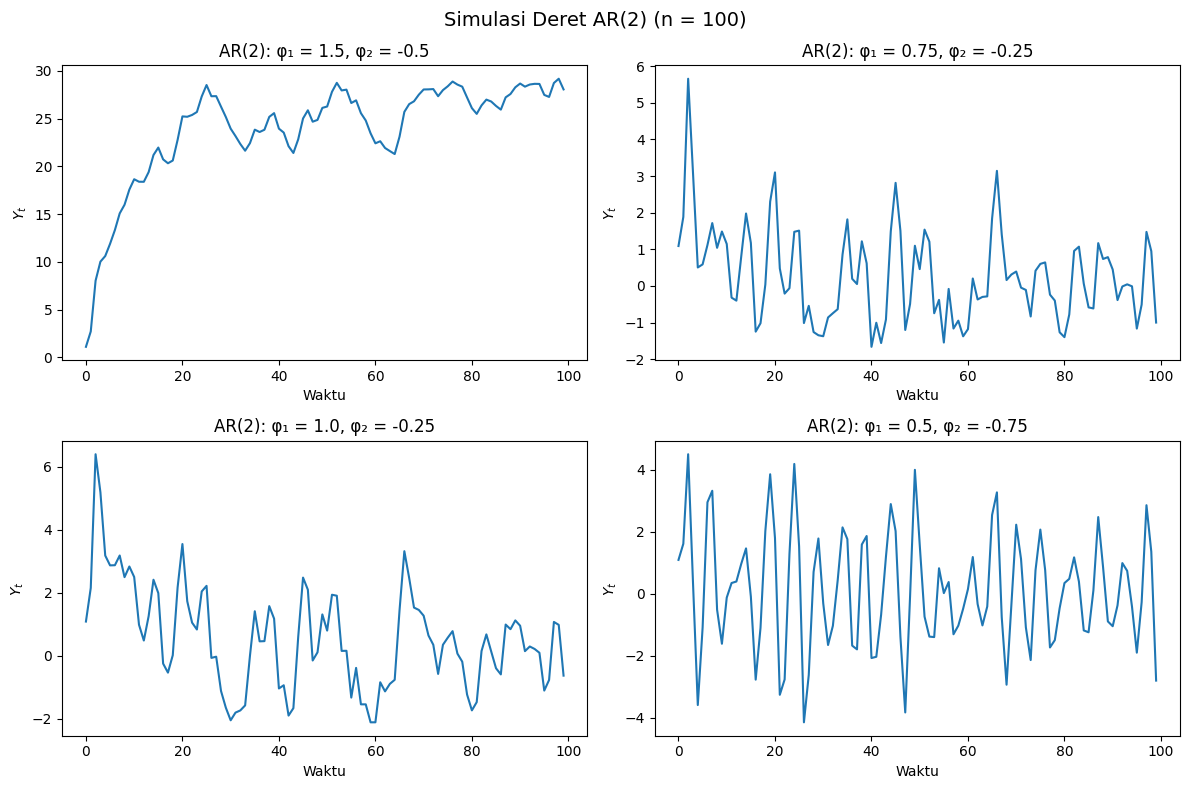

kasus |   phi1 |   phi2 |  phi1+phi2<1 |  phi2-phi1<1 |  |phi2|<1 | stasioner?
    a |   1.50 |  -0.50 |        False |         True |      True |      False
    b |   0.75 |  -0.25 |         True |         True |      True |       True
    c |   1.00 |  -0.25 |         True |         True |      True |       True
    d |   0.50 |  -0.75 |         True |         True |      True |       True


In [ ]:
# Nomor 10
# Simulasi deret AR(2) dengan panjang pengamatan 100

n10 = 100
kasus_ar2 = {
    'a': (1.5, -0.5),
    'b': (0.75, -0.25),
    'c': (1.0, -0.25),
    'd': (0.5, -0.75),
}
label_ar2 = list(kasus_ar2.keys())

models_ar2 = []
labels_ar2 = []

for label in label_ar2:
    phi1, phi2 = kasus_ar2[label]

    # seed kelompok
    np.random.seed(137)

    # Parameter model AR(2)
    ar_params = np.array([1, -phi1, -phi2])
    ma_params = np.array([1])

    # Membentuk proses AR(2)
    ar_object = ArmaProcess(ar_params, ma_params)

    # Simulasi data
    data_ar2 = ar_object.generate_sample(nsample=n10)

    # Menyimpan data dan label untuk plotting
    models_ar2.append(data_ar2)
    labels_ar2.append(f'AR(2): φ₁ = {phi1}, φ₂ = {phi2}')

# Plot deret waktu sesuai visualisasi sampel gambar
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

for i, (ax, data) in enumerate(zip(axes.flat, models_ar2), 1):
    ax.plot(data)  # Warna biru standar Matplotlib tanpa marker hitam
    ax.set_title(labels_ar2[i-1])
    ax.set_xlabel('Waktu')
    ax.set_ylabel(r'$Y_t$')

fig.suptitle(f'Simulasi Deret AR(2) (n = {n10})', fontsize=14)
plt.tight_layout()
plt.show()

# Pemeriksaan syarat kestasioneran AR(2): phi1+phi2<1, phi2-phi1<1, |phi2|<1
print(f"{'kasus':>5} | {'phi1':>6} | {'phi2':>6} | {'phi1+phi2<1':>12} | {'phi2-phi1<1':>12} | {'|phi2|<1':>9} | {'stasioner?':>10}")
for label in label_ar2:
    phi1, phi2 = kasus_ar2[label]
    syarat1 = phi1 + phi2 < 1
    syarat2 = phi2 - phi1 < 1
    syarat3 = abs(phi2) < 1
    print(f"{label:>5} | {phi1:6.2f} | {phi2:6.2f} | {str(syarat1):>12} | {str(syarat2):>12} | {str(syarat3):>9} | {str(syarat1 and syarat2 and syarat3):>10}")

**Plot ACF (*Autocorelation Function*) dan PACF(*Partial Autocorelation Function*)**

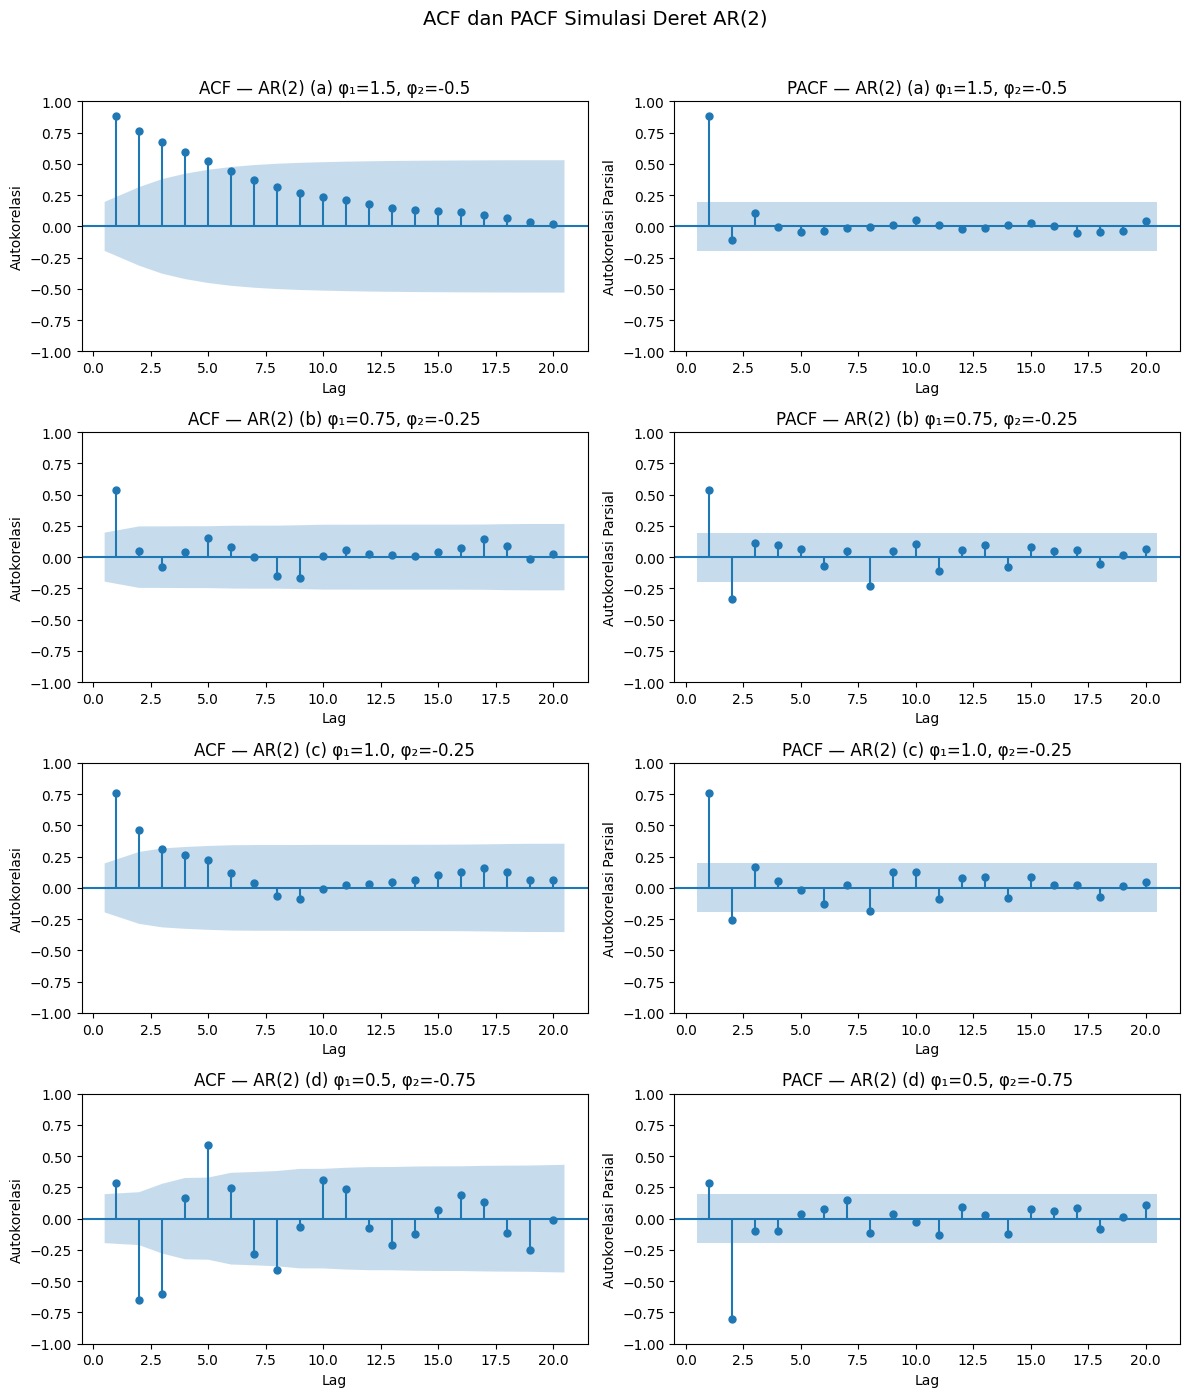

In [ ]:
# Nomor 11
# Plot ACF dan PACF gabungan dari masing-masing deret hasil simulasi pada nomor 10

fig, axes = plt.subplots(len(label_ar2), 2, figsize=(12, 14))

for i, label in enumerate(label_ar2):

    phi1, phi2 = kasus_ar2[label]

    # Mengambil data AR(2) hasil simulasi nomor 10
    data = models_ar2[i]

    # Plot ACF di kolom kiri
    plot_acf(
        data,
        zero=False,
        lags=20,
        ax=axes[i, 0]
    )

    axes[i, 0].set_title(
        f'ACF — AR(2) ({label}) φ₁={phi1}, φ₂={phi2}'
    )
    axes[i, 0].set_xlabel('Lag')
    axes[i, 0].set_ylabel('Autokorelasi')
    axes[i, 0].set_ylim(-1, 1)

    # Plot PACF di kolom kanan
    plot_pacf(
        data,
        zero=False,
        lags=20,
        ax=axes[i, 1],
        method='ywm'
    )

    axes[i, 1].set_title(
        f'PACF — AR(2) ({label}) φ₁={phi1}, φ₂={phi2}'
    )
    axes[i, 1].set_xlabel('Lag')
    axes[i, 1].set_ylabel('Autokorelasi Parsial')
    axes[i, 1].set_ylim(-1, 1)

fig.suptitle(
    'ACF dan PACF Simulasi Deret AR(2)',
    fontsize=14,
    y=0.995
)

plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.show()